# TRAIN ON RAF-DB

+ Logs:

[19-05-12]: Trainable for 2 last layers to fine-tuning


## Project Configure

In [1]:
from __future__ import absolute_import, division, print_function

%reload_ext autoreload
%autoreload 2

########################################################################
# Declare Project Configure
########################################################################
import os, sys
root_dir = "/mnt/ubuntu1/dntai/projects_merge/EmotiWPrj"
lib_dirs = [os.path.join(root_dir, 'sources')]
for lib in lib_dirs:
    if lib not in sys.path: sys.path.insert(0, lib)
# for
# np.set_printoptions(precision=2, suppress=True, formatter={'float': '{: 0.4f}'.format}, linewidth=1000)

from emotiw19prj.image2d.common   import *

from emotiw19prj.image2d.rafdb.dataset import RafdbBasicDataset
from emotiw19prj.image2d.dataaug  import train_aug, valid_aug
from emotiw19prj.image2d.dataload import Face2DEmotiWBalancedDataLoader

from emotiw19prj.image2d.datagen  import DataGenerator
from emotiw19prj.image2d.dataaug  import vggface2_preprocessing_input, vggface2_postprocessing_input

from emotiw19prj.image2d.model.model_vggface2_ft import VGGFace2_FineTuning_EmotionRecognition_V0

## 1. Setup Environments

In [2]:
########################################################################
# 1. Setup Environments
########################################################################

# Parameters
parser = argparse.ArgumentParser(description='Facial Emotion Recognition - RAF-DB Dataset')
parser.add_argument('--project_name', type=str, default="Facial Emotion Recognition  - RAF-DB Dataset", metavar='project_name', help='')

parser.add_argument('--result_dir'  , type=str, default=root_dir + "/data/results/image2d/rafdb/affectnet_vggface2_resnes50_ft", 
                    metavar='result_dir', help='')

parser.add_argument('--runtime_dir' , type=str, default=root_dir + "/data/results/image2d/rafdb/affectnet_vggface2_resnes50_ft/190512_01", 
                    metavar='runtime_dir', help='')

parser.add_argument('--model_name'  , type=str, default="rafdb_facevgg2_resnet50_ft_01", metavar='model_name', help='')

parser.add_argument('--db_file' ,type=str, default=root_dir + "/data/rafdb_balanced/rafdb_basic.hdf5", metavar='db_file', help='')
parser.add_argument('--db_root' ,type=str, default="/mnt/public_data/datasets/raf-db/basic", metavar='db_root', help='')

parser.add_argument('--training_scheme' ,type=str, default=root_dir + "/data/rafdb_balanced/normal_training.npz", metavar='training_scheme', help='')

parser.add_argument('--gpus',   type=str, default="['0']", help='')

parser.add_argument('--batch_size'       , type=int, default=64, help='')
parser.add_argument('--final_epoch'      , type=int, default=1200, help='')
parser.add_argument('--steps_per_epoch'  , type=int, default=None, help='')
parser.add_argument('--validation_steps' , type=int, default=None, help='')
parser.add_argument('--initial_epoch'    , type=int, default=527, help='')
parser.add_argument('--best_point'       , type=float, default=None, help='')

parser.add_argument('--restore_log'     , type=str , default=root_dir + "/data/results/" + 
                    "image2d/rafdb/affectnet_vggface2_resnes50_ft/190512_01/weights/model3/"
                    +"rafdb_facevgg2_resnet50_ft_01_weights_190513123348_epoch-527_val_loss-1.04_val_acc-0.86.h5.logs.csv", help='')

parser.add_argument('--weights_path'     , type=str, default=root_dir +  "/data/results/" +
                    "image2d/rafdb/affectnet_vggface2_resnes50_ft/190512_01/weights/model3/" + 
                    "rafdb_facevgg2_resnet50_ft_01_weights_190513123348_epoch-527_val_loss-1.04_val_acc-0.86.h5", help='')

parser.add_argument('--early_stop_patience' , type=int  , default=-1, help='')

args, _ = parser.parse_known_args()
params  = vars(args)
params["gpus"] = eval(params["gpus"])
print("parameters: ")
for key in params.keys(): print("+ %s: %s"%(key,params[key]))

parameters: 
+ project_name: Facial Emotion Recognition  - RAF-DB Dataset
+ training_scheme: /mnt/ubuntu1/dntai/projects_merge/EmotiWPrj/data/rafdb_balanced/normal_training.npz
+ result_dir: /mnt/ubuntu1/dntai/projects_merge/EmotiWPrj/data/results/image2d/rafdb/affectnet_vggface2_resnes50_ft
+ best_point: None
+ runtime_dir: /mnt/ubuntu1/dntai/projects_merge/EmotiWPrj/data/results/image2d/rafdb/affectnet_vggface2_resnes50_ft/190512_01
+ db_file: /mnt/ubuntu1/dntai/projects_merge/EmotiWPrj/data/rafdb_balanced/rafdb_basic.hdf5
+ gpus: ['0']
+ final_epoch: 1200
+ model_name: rafdb_facevgg2_resnet50_ft_01
+ early_stop_patience: -1
+ db_root: /mnt/public_data/datasets/raf-db/basic
+ steps_per_epoch: None
+ batch_size: 64
+ restore_log: /mnt/ubuntu1/dntai/projects_merge/EmotiWPrj/data/results/image2d/rafdb/affectnet_vggface2_resnes50_ft/190512_01/weights/model3/rafdb_facevgg2_resnet50_ft_01_weights_190513123348_epoch-527_val_loss-1.04_val_acc-0.86.h5.logs.csv
+ initial_epoch: 527
+ validatio

In [3]:
# Choose gpus, init session
choose_keras_environment(gpus = params["gpus"], keras_backend = "tensorflow", verbose = 1)
init_session()
check_tensorflow_environment()

Environment GPUs:
+ Choose GPUs:  0
+ Keras backend:  tensorflow
TensorFlow Version: 1.9.0
Default GPU Device: /device:GPU:0


In [4]:
# Project configuration
result_dir = params["result_dir"]
if os.path.exists(result_dir) == False: os.makedirs(result_dir)
print('result_dir:\t', result_dir)

result_dir:	 /mnt/ubuntu1/dntai/projects_merge/EmotiWPrj/data/results/image2d/rafdb/affectnet_vggface2_resnes50_ft


## 2. Setup Data

In [5]:
# Dataset Configuration
dataset_info  = dict(db_file = params["db_file"], db_root = params["db_root"])
print("dataset_info: ")
for key in dataset_info.keys(): print("+ %s: %s"%(key,dataset_info[key]))

dataset_info: 
+ db_file: /mnt/ubuntu1/dntai/projects_merge/EmotiWPrj/data/rafdb_balanced/rafdb_basic.hdf5
+ db_root: /mnt/public_data/datasets/raf-db/basic


In [6]:
ds = RafdbBasicDataset(**dataset_info)
ds.load_scheme(params["training_scheme"])

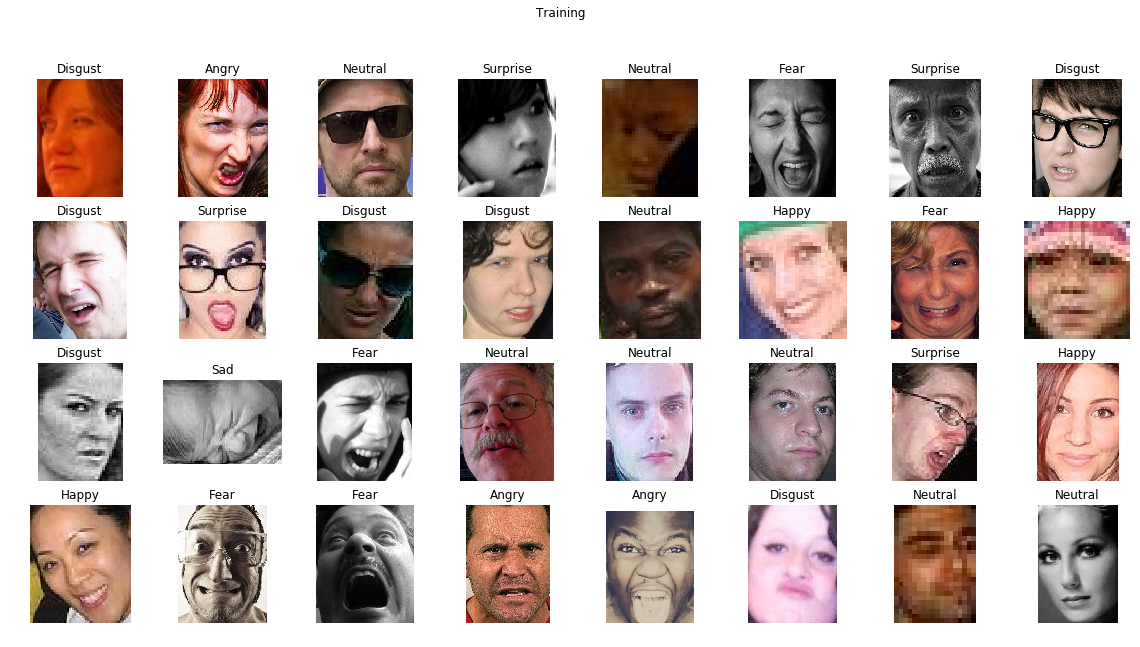

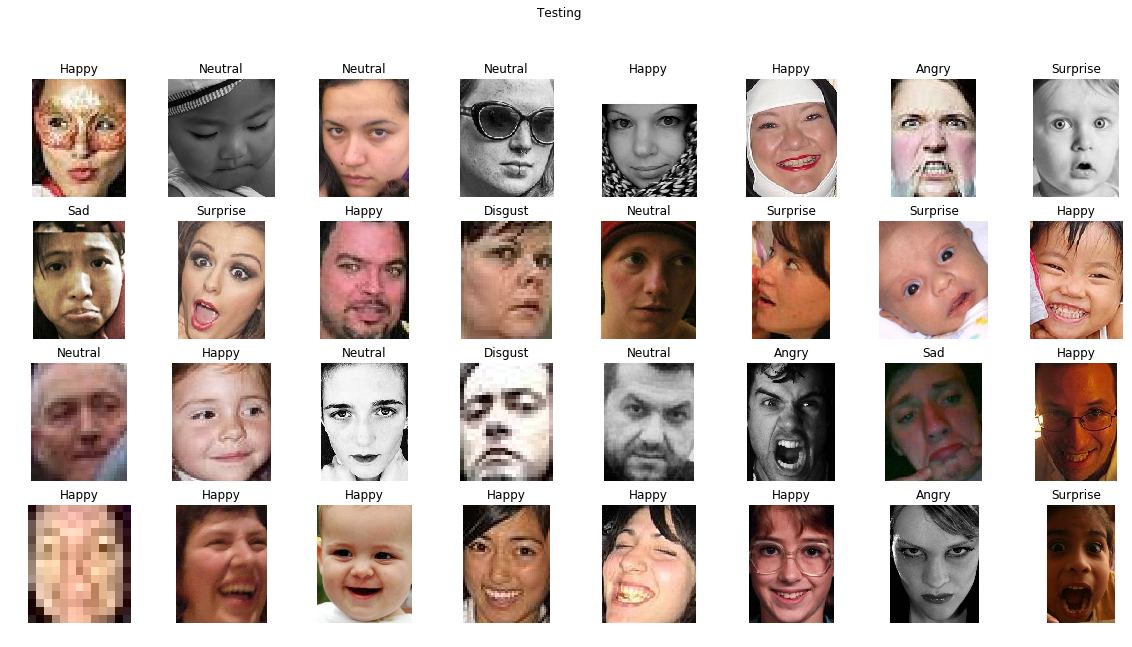

In [7]:
ds.view_images(ds.x_train, ds.y_train, mode = "train", title = "Training");
ds.view_images(ds.x_valid, ds.y_valid, mode = "valid", title = "Testing");

Number of images in the training dataset:	 12271


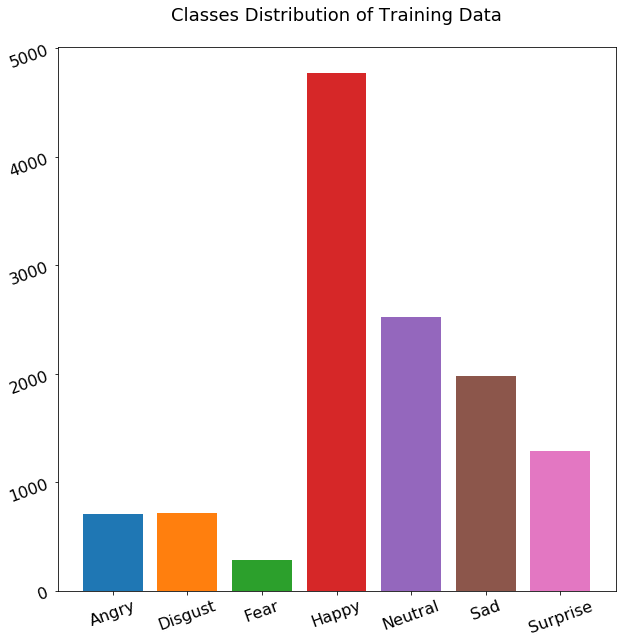

Number of images in the training dataset:	  3068


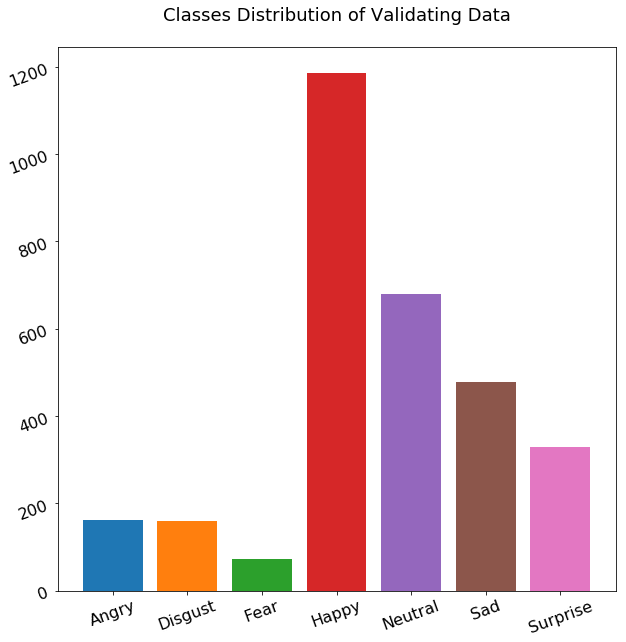

In [8]:
ds.view_summary(x = ds.x_train, y = ds.y_train, mode = "train", title = "Training Data")
ds.view_summary(x = ds.x_valid, y = ds.y_valid, mode = "valid", title = "Validating Data")
# if ds.n_test>0: ds.view_summary(x = ds.x_test, y = ds.y_test, title = "Testing Data")

## 3. Setup Training

In [9]:
# Training Configuration
train_config = dict(
    runtime_dir         = params["runtime_dir"],
    logs_dir            = params["runtime_dir"] + "/logs",
    checkpoints_dir     = params["runtime_dir"] + "/checkpoints",
    tensorboard_dir     = params["runtime_dir"] + "/tensorboard", 
    weight_dir          = params["runtime_dir"] + "/weights"
)
for key in ["runtime_dir", "logs_dir", "checkpoints_dir", "tensorboard_dir", "weight_dir"]:
    if not os.path.exists(train_config[key]): os.makedirs(train_config[key])
    print("%s: %s"%(key, train_config[key]))
# for

runtime_dir: /mnt/ubuntu1/dntai/projects_merge/EmotiWPrj/data/results/image2d/rafdb/affectnet_vggface2_resnes50_ft/190512_01
logs_dir: /mnt/ubuntu1/dntai/projects_merge/EmotiWPrj/data/results/image2d/rafdb/affectnet_vggface2_resnes50_ft/190512_01/logs
checkpoints_dir: /mnt/ubuntu1/dntai/projects_merge/EmotiWPrj/data/results/image2d/rafdb/affectnet_vggface2_resnes50_ft/190512_01/checkpoints
tensorboard_dir: /mnt/ubuntu1/dntai/projects_merge/EmotiWPrj/data/results/image2d/rafdb/affectnet_vggface2_resnes50_ft/190512_01/tensorboard
weight_dir: /mnt/ubuntu1/dntai/projects_merge/EmotiWPrj/data/results/image2d/rafdb/affectnet_vggface2_resnes50_ft/190512_01/weights


### 3.1. Data Augmentation

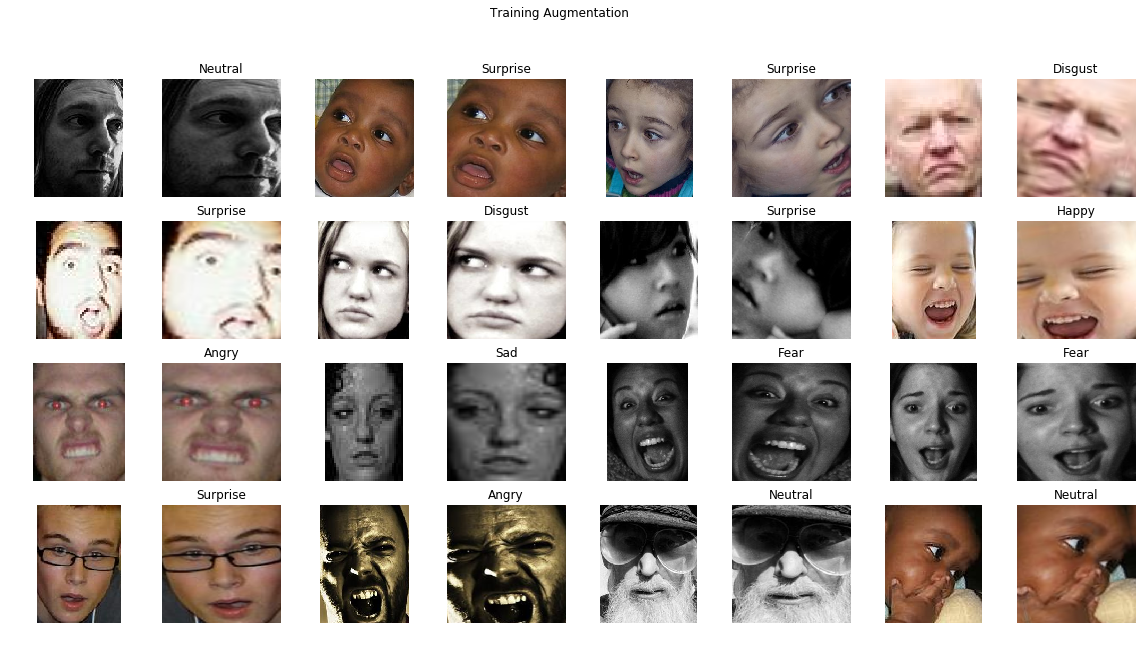

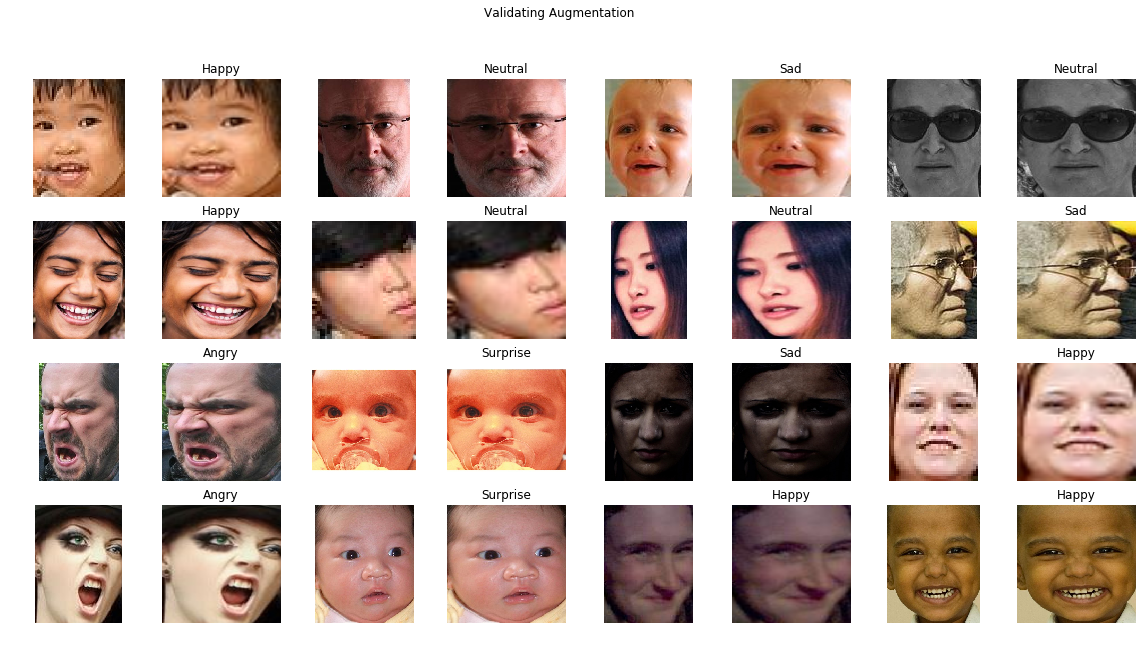

In [10]:
ds.test_aug(ds.x_train, ds.y_train, train_aug(224), mode = "train", title = "Training Augmentation", rows = 4, cols = 4)
ds.test_aug(ds.x_valid, ds.y_valid, valid_aug(224), mode = "valid", title = "Validating Augmentation", rows = 4, cols = 4)

In [11]:
ds.x_valid.keys(), ds.y_valid.shape

(dict_keys(['image', 'bbox']), (3068,))

### 3.2. Data Loader

In [12]:
ds.n_emotion_train, np.average(np.array(ds.n_emotion_train))

([705, 717, 281, 4772, 2524, 1982, 1290], 1753.0)

In [13]:
train_transforms = train_aug(224)
valid_transforms = valid_aug(224)

train_loader = Face2DEmotiWBalancedDataLoader(ds.x_train, ds.y_train, 7, train_transforms, mode = "train", capacity = 1753 * 7, 
                                              type_bbox = "xyxy", expanding_bbox = (0.2, 0.2, 0.2, 0.2))
valid_loader = Face2DEmotiWBalancedDataLoader(ds.x_valid, ds.y_valid, 7, valid_transforms, mode = "valid", 
                                              type_bbox = "xyxy", expanding_bbox = (0.2, 0.2, 0.2, 0.2))

In [14]:
x, y = train_loader[20]
print(x.shape, y.shape)

x, y = valid_loader[20]
print(x.shape, y.shape)

(224, 224, 3) (7,)
(224, 224, 3) (7,)


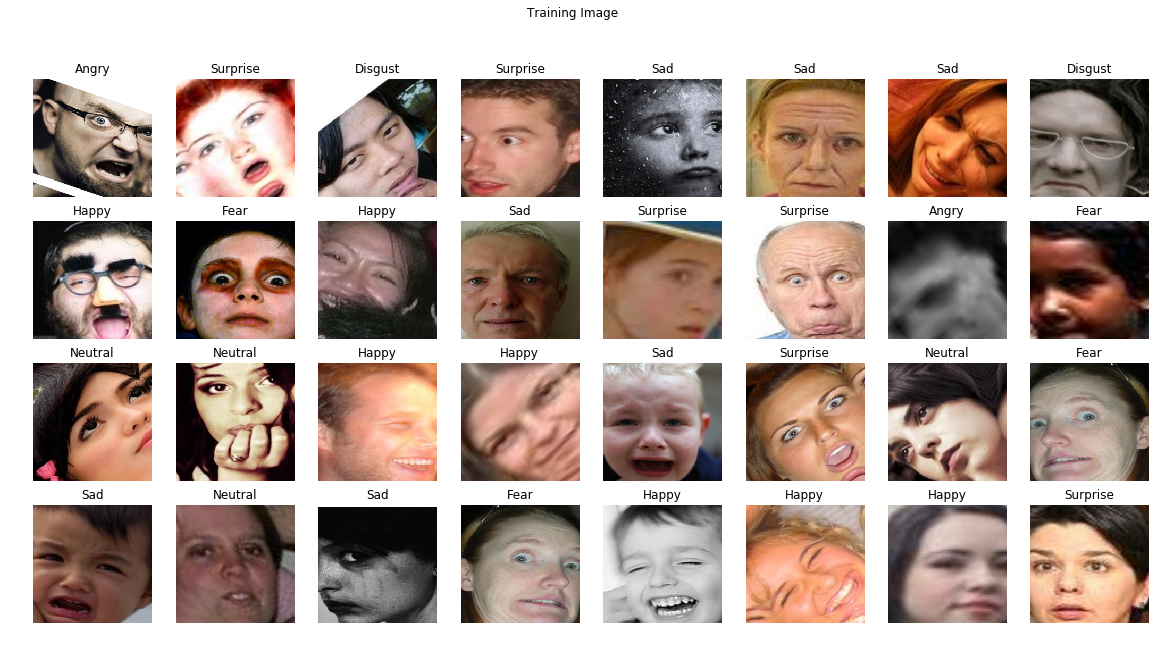

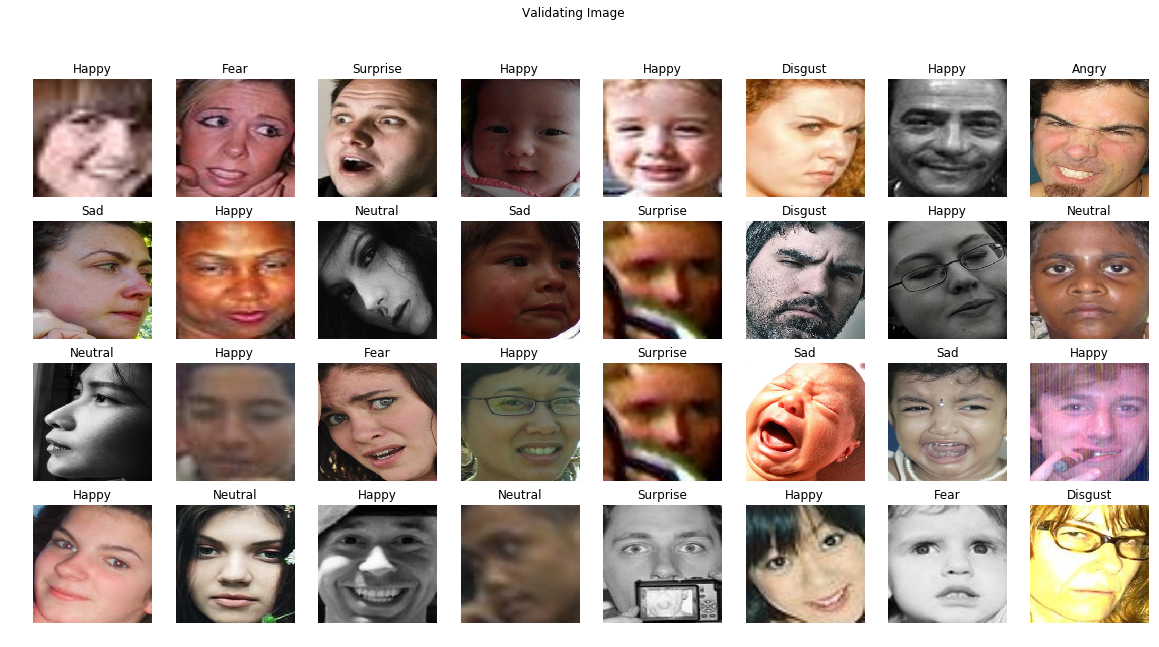

In [15]:
train_loader.view("Training Image")
valid_loader.view("Validating Image")

### 3.3. Data Generator

In [16]:
train_gen = DataGenerator(dataloader = train_loader, 
                          preprocessing_image_fn = vggface2_preprocessing_input,
                          batch_size = params["batch_size"], 
                          shuffle = True, seed = None )

In [17]:
x, y = next(train_gen)
x.shape, y.shape, np.min(x), np.max(x)

((64, 224, 224, 3), (64, 7), -131.0912, 163.5047)

In [18]:
valid_gen = DataGenerator(dataloader = valid_loader, 
                          preprocessing_image_fn = vggface2_preprocessing_input,
                          batch_size = params["batch_size"], 
                          shuffle = True, seed = None )

In [19]:
x, y = next(valid_gen)
x.shape, y.shape, np.min(x), np.max(x)

((64, 224, 224, 3), (64, 7), -131.0912, 163.5047)

### 3.3 Models

In [20]:
train_config.update(dict(
    # Startup train
    batch_size           = params["batch_size"],
    final_epoch          = params["final_epoch"],
    steps_per_epoch      = ceil(len(train_loader) / params["batch_size"]) if params["steps_per_epoch"] is None else params["steps_per_epoch"],
    validation_steps     = ceil(len(valid_loader) / params["batch_size"]) if params["validation_steps"] is None else params["validation_steps"],
    input_shape          = (224, 224, 3),

    # CAUTION: Restore Train
    best_point           = params["best_point"],
    initial_epoch        = params["initial_epoch"],
    weights_path         = params["weights_path"]
))

for key in ["batch_size", "final_epoch", "steps_per_epoch", "validation_steps", "input_shape", "best_point", "initial_epoch", "weights_path"]:
    print("%s: %s"%(key, train_config[key]))
# for

batch_size: 64
final_epoch: 1200
steps_per_epoch: 192
validation_steps: 48
input_shape: (224, 224, 3)
best_point: None
initial_epoch: 527
weights_path: /mnt/ubuntu1/dntai/projects_merge/EmotiWPrj/data/results/image2d/rafdb/affectnet_vggface2_resnes50_ft/190512_01/weights/model3/rafdb_facevgg2_resnet50_ft_01_weights_190513123348_epoch-527_val_loss-1.04_val_acc-0.86.h5


In [21]:
import shutil
src_logs  = params["restore_log"]
save_logs = train_config["logs_dir"] + "/%s_logs.csv"%params["model_name"]
if os.path.exists(src_logs) == True:shutil.copy(src_logs, save_logs)

In [22]:
# Callbacks
visualize_callbacks = VisualizeCallback(
                  group_data=[{"x": "epoch", "y": ["acc", "val_acc"], "title": "Accuracy at Epoch: {epoch}\n"},
                              {"x": "epoch", "y": ["loss", "val_loss"], "title": "Loss at Epoch: {epoch}\n"},
                              {"x": "epoch", "y": ["lr"], "title": "Learning Rate\n"}],
                  group_shape=(1, 3), figsize=(20, 10),
                  save_image = train_config["logs_dir"] + "/%s_train_{epoch:02d}.png"%params["model_name"],
                  save_logs  = save_logs, save_mode = "a")

checkpoint_callbacks = CustomModelCheckpoint(
                  filepath = train_config["checkpoints_dir"] + "/_%s_weights_{date:%%y%%m%%d%%H%%M%%S}_epoch-{epoch:02d}_val_loss-{val_loss:.2f}_val_acc-{val_acc:.2f}.h5"%params["model_name"], 
                  monitor  = "val_acc", 
                  save_best_only = True, 
                  mode     = "max", 
                  period=1, verbose= 0, save_weights_only = False)
checkpoint_callbacks.best_point = train_config["best_point"]

tensorboard_callbacks = TensorBoard(log_dir=train_config["tensorboard_dir"])

callbacks = [visualize_callbacks, checkpoint_callbacks, tensorboard_callbacks]

clr_callbacks = CyclicLR(base_lr=0.00005, max_lr=0.0005, step_size=192 * 4)
callbacks.append(clr_callbacks)

if params["early_stop_patience"]>=0:
    earlystop_callbacks   = EarlyStopping(patience=params["early_stop_patience"])
    callbacks.append(earlystop_callbacks)

In [23]:
# Model
K.clear_session()

model = VGGFace2_FineTuning_EmotionRecognition_V0(weights_path=params["weights_path"], 
                                                  nb_classes=7, dropout=[0.15, 0.15], 
                                                  mode = "train")

In [24]:
for idx in range(len(model.layers)):
    model.layers[idx].trainable = True

In [25]:
# # Diasbled Training for Base Model - Fine-Tuning Last Layers
# idx_block4_first = -1
# for idx in range(len(model.layers)):
#     if model.layers[idx].name == "conv4_1_1x1_reduce":
#         idx_block4_first = idx
#         break
# for idx in range(len(model.layers)):
#     if idx<idx_block4_first:
#         model.layers[idx].trainable = False
#     else:
#         model.layers[idx].trainable = True
# # for
# print(model.layers[idx_block4_first].name)

In [26]:
save_keras_model(model, save_dir = params["runtime_dir"], save_name = "%s_model_"%params["model_name"])

Save model:  /mnt/ubuntu1/dntai/projects_merge/EmotiWPrj/data/results/image2d/rafdb/affectnet_vggface2_resnes50_ft/190512_01/rafdb_facevgg2_resnet50_ft_01_model_.png  finished!
Save model:  /mnt/ubuntu1/dntai/projects_merge/EmotiWPrj/data/results/image2d/rafdb/affectnet_vggface2_resnes50_ft/190512_01/rafdb_facevgg2_resnet50_ft_01_model_.yaml  finished!
Save model:  /mnt/ubuntu1/dntai/projects_merge/EmotiWPrj/data/results/image2d/rafdb/affectnet_vggface2_resnes50_ft/190512_01/rafdb_facevgg2_resnet50_ft_01_model_.json  finished!
Save model:  /mnt/ubuntu1/dntai/projects_merge/EmotiWPrj/data/results/image2d/rafdb/affectnet_vggface2_resnes50_ft/190512_01/rafdb_facevgg2_resnet50_ft_01_model_.txt  finished!


In [27]:
# compile model info
compile_model_info = dict(
    # loss
    loss         = "categorical_crossentropy",
    # optimizer
    # optimizer    = Adam(lr=0.0001),
    optimizer = SGD(lr=0.0004, decay = 1e-6, momentum=0.9, nesterov=True),
  
    # metrics
    metrics      = ['accuracy']
)
model.compile(**compile_model_info)

## 4. Training

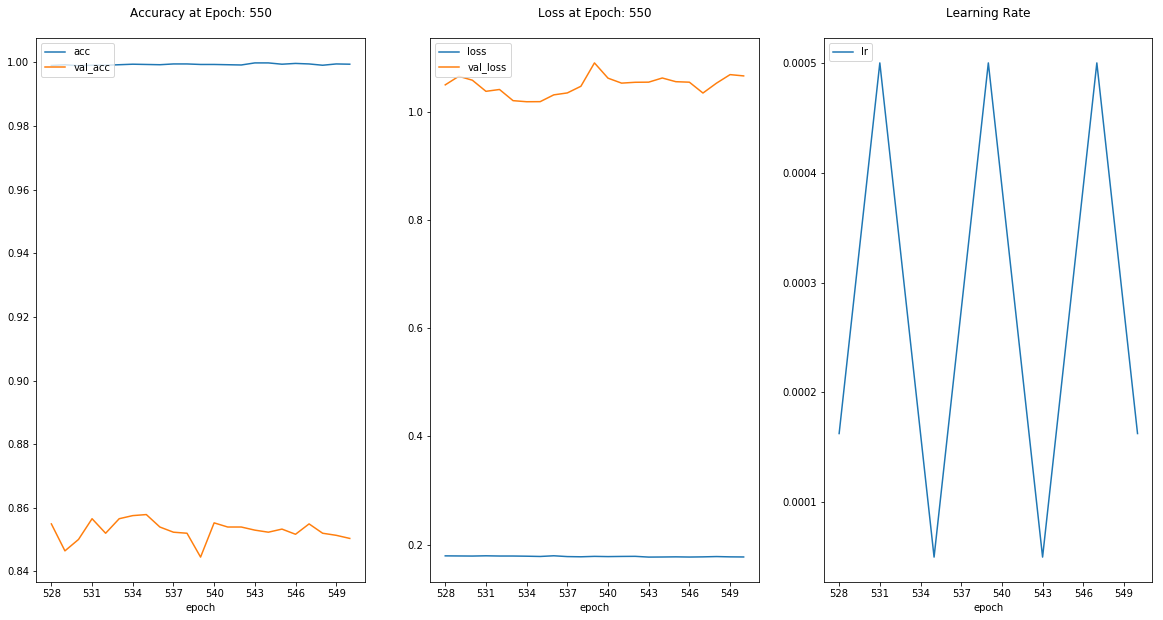

Epoch 528/1200
192/192 [==============================] - 122s 636ms/step - loss: 0.1791 - acc: 0.9990 - val_loss: 1.0500 - val_acc: 0.8550
Epoch 529/1200
192/192 [==============================] - 106s 551ms/step - loss: 0.1790 - acc: 0.9993 - val_loss: 1.0658 - val_acc: 0.8465
Epoch 530/1200
192/192 [==============================] - 104s 543ms/step - loss: 0.1788 - acc: 0.9989 - val_loss: 1.0586 - val_acc: 0.8501
Epoch 531/1200
192/192 [==============================] - 105s 545ms/step - loss: 0.1792 - acc: 0.9991 - val_loss: 1.0380 - val_acc: 0.8566
Epoch 532/1200
192/192 [==============================] - 107s 558ms/step - loss: 0.1788 - acc: 0.9991 - val_loss: 1.0414 - val_acc: 0.8520
Epoch 533/1200
192/192 [==============================] - 105s 547ms/step - loss: 0.1788 - acc: 0.9993 - val_loss: 1.0208 - val_acc: 0.8566
Epoch 534/1200
192/192 [==============================] - 89s 466ms/step - loss: 0.1785 - acc: 0.9994 - val_loss: 1.0188 - val_acc: 0.8576
Epoch 535/1200
192/19

In [ ]:
model.fit_generator(generator       = train_gen, 
                    
                    initial_epoch   = train_config["initial_epoch"],
                    epochs          = train_config["final_epoch"],
                    steps_per_epoch = train_config["steps_per_epoch"],
                              
                    validation_data = valid_gen,
                    
                    validation_steps= train_config["validation_steps"],

                    callbacks       = callbacks)

In [ ]:
print("Done!")

# END PROJECT